In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [2]:
rolls = np.random.randint(1, 7, size=100_000)
p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.501  (true 0.5)
P(>4)   ~ 0.333  (true 0.333)


In [3]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.332
P(1 or 2)   = 0.332  -> they match


In [4]:
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)
# 1. P(both heads)
p_both_heads = np.mean(heads == 2)
# 2. P(at least one head)
p_at_least_one = np.mean(heads >= 1)
# 3. Do P(0) + P(1) + P(2) sum to 1?
p0 = np.mean(heads == 0)
p1 = np.mean(heads == 1)
p2 = np.mean(heads == 2)
print("P(both heads):", p_both_heads)
print("P(at least one head):", p_at_least_one)
print("P(0) + P(1) + P(2):", p0 + p1 + p2)


P(both heads): 0.25077
P(at least one head): 0.74945
P(0) + P(1) + P(2): 1.0


In [5]:
rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.333  (true 1/3)


In [6]:
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.501
P(A | B)  = 0.668
Independent? False


In [7]:
rolls = np.random.randint(1, 7, size=100_000)
# 1. P(odd | roll < 4)
p_odd_given_less4 = np.mean(rolls[rolls < 4] % 2 == 1)
# 2. P(roll < 4)
p_less4 = np.mean(rolls < 4)
# 3. Compare P(odd | <4) with P(odd) overall
p_odd = np.mean(rolls % 2 == 1)
print("P(odd | roll < 4):", p_odd_given_less4)
print("P(roll < 4):", p_less4)
print("P(odd) overall:", p_odd)
print("Independent?", np.isclose(p_odd_given_less4, p_odd))


P(odd | roll < 4): 0.6687926282115768
P(roll < 4): 0.49703
P(odd) overall: 0.49947
Independent? False


In [8]:
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [9]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)
among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.496


In [10]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05
# 2. P('free') via total probability
p_ham = 1 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print("P(free):", p_free)
print("P(spam | free):", p_spam_given_free)


P(free): 0.16
P(spam | free): 0.75


In [15]:
from scipy import stats
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.289 (true 0.3)
Poisson(4) mean ~ 4.01 (true 4)


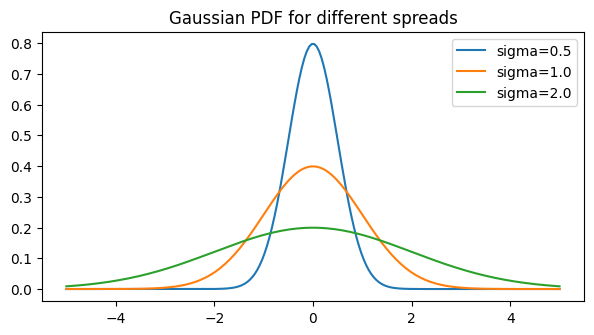

In [16]:
from scipy import stats
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Sample mean: 1.99991


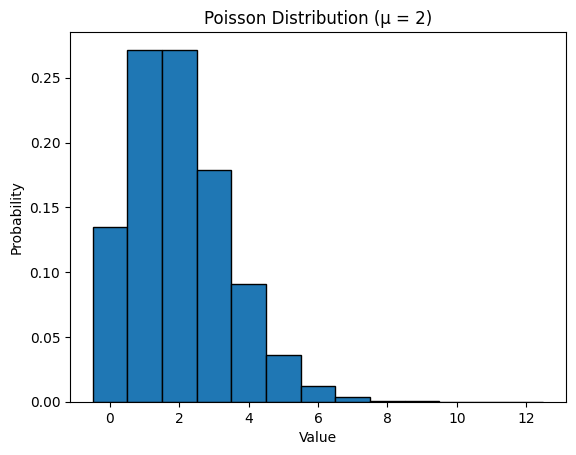

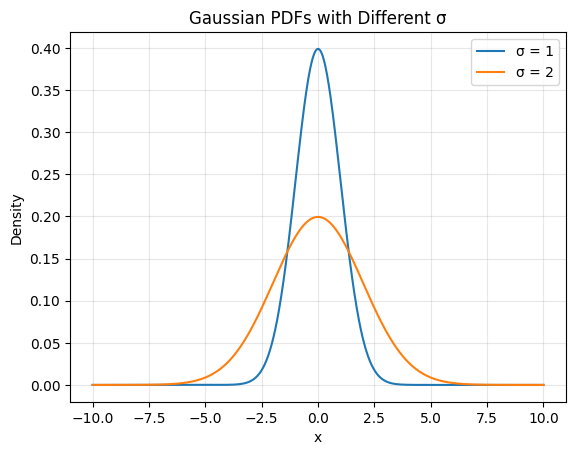

In [17]:
import numpy as np
import matplotlib.pyplot as plt
# 1. Poisson(mu=2) samples + mean
samples = np.random.poisson(lam=2, size=100_000)
print("Sample mean:", samples.mean())
# 2. Histogram of the samples
plt.hist(samples, bins=np.arange(samples.max() + 2) - 0.5,
         density=True, edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Probability")
plt.title("Poisson Distribution (μ = 2)")
plt.show()
# 3. Gaussian PDF for two sigmas on one plot
x = np.linspace(-10, 10, 1000)
mu = 0
sigma1 = 1
sigma2 = 2
pdf1 = (1 / (sigma1 * np.sqrt(2 * np.pi))) * \
       np.exp(-0.5 * ((x - mu) / sigma1) ** 2)
pdf2 = (1 / (sigma2 * np.sqrt(2 * np.pi))) * \
       np.exp(-0.5 * ((x - mu) / sigma2) ** 2)
plt.plot(x, pdf1, label="σ = 1")
plt.plot(x, pdf2, label="σ = 2")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Gaussian PDFs with Different σ")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
from scipy.stats import entropy
fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [19]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [20]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris
iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [21]:
import numpy as np
from scipy.stats import entropy
# 1. Entropy of a fair 4-sided and 6-sided die (base=2)
H_4 = entropy([1/4] * 4, base=2)
H_6 = entropy([1/6] * 6, base=2)
print("H(4-sided die):", H_4)
print("H(6-sided die):", H_6)
# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])
D_PQ = entropy(P, Q, base=2)
print("D(P || Q):", D_PQ)
# 3. Most / least informative iris feature (from 5C)
print("Most informative: petal length")
print("Least informative: sepal width")


H(4-sided die): 2.0
H(6-sided die): 2.584962500721156
D(P || Q): 0.11870910076930725
Most informative: petal length
Least informative: sepal width


#📘 Summary — Probability & Information Theory toolkit

| Concept | What it tells you | Key calls |
| ------- | ----------------- | --------- |
| **Probability** | how likely an event is | simulate + `.mean()` |
| **Conditional** | likelihood given other info | filter, then `.mean()` |
| **Bayes** | update belief with evidence | `P(B\|A)P(A)/P(B)` |
| **Distributions** | shapes of randomness | `stats.bernoulli/poisson/norm` |
| **Entropy** | uncertainty (bits) | `scipy.stats.entropy(p, base=2)` |
| **KL divergence** | distance between distributions | `entropy(P, Q)` |
| **Mutual information** | feature informativeness | `mutual_info_classif` |

**Homework (self-paced):** 3 conditional/independent-event problems · a Bayes scenario · simulate & plot 3 distributions · entropy of 3 datasets · KL + MI and rank features.

**Phase B complete!** Next is **Phase C — Data Engineering & Preparation** (U7: Data Science Lifecycle & data sources).